In [1]:
import numpy as np
from numpy import pi
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from skimage.measure import label

class Particle_Tracking_Training_Data(tf.Module):
    def __init__(self, Nt, rings=True):
        self.Nt = int(Nt)
        self.Ny = self.Nx = 256
        self.d = 3
        ximg = [[[i, j] for i in np.arange(self.Ny)]
            for j in np.arange(self.Nx)]
        self.ximg = np.float32(ximg)

        x = np.arange(self.Nx) - self.Nx//2
        y = np.arange(self.Ny) - self.Ny//2
        X0, Y0 = np.meshgrid(x, y)
        self.X = np.float32(X0)
        self.Y = np.float32(Y0)

        if rings:
            self.ring_indicator = 1.
        else:
            self.ring_indicator = 0.

        self._gen_video = tf.function(
            input_signature=(
                tf.TensorSpec(
                    shape=[self.Ny, self.Nx, self.Nt, None], dtype=tf.float32),
                tf.TensorSpec(shape=[self.Nt, None], dtype=tf.float32),
                tf.TensorSpec(shape=[], dtype=tf.float32),
                tf.TensorSpec(shape=[], dtype=tf.float32),
                tf.TensorSpec(shape=[], dtype=tf.float32),)
        )(self._gen_video)

        self._gen_labels = tf.function(
            input_signature=(
                tf.TensorSpec(
                    shape=[self.Ny, self.Nx, self.Nt, None], dtype=tf.float32),)
        )(self._gen_labels)

    def __call__(self, kappa, a, IbackLevel, Nparticles, sigma_motion):
        """a: spot radius scale factor (1.5-4 is a reasonable range)
        kappa: noise level (around 0.1 or so)
        IbackLevel: intensity level of the random background relative to maximum (must be between zero and one)
        Nparticles: the number of particles in the video (larger numbers means slower run time)
        sigma_motion: the standard deviation of the random Brownian motion per video frame"""
        ## random brownian motion paths
        ## Nt, Nparticles, 3
        xi = self._sample_motion(Nparticles, sigma_motion)

        #### translate track positions to img coords
        ## Ny, Nx, Nt, Np, 2
        XALL = (self.ximg[:, :, None, None, :]
                - xi[None, None, :, :, :2])
        ## Ny, Nx, Nt, Np
        r = tf.math.sqrt(XALL[..., 0]**2 + XALL[..., 1]**2)
        z = xi[..., 2]

        ### generate video
        I = self._gen_video(r, z, kappa, a, IbackLevel)

        ### generate labels
        labels = self._gen_labels(r)

        return I, labels, xi

    @staticmethod
    def rand(n):
        return tf.random.uniform([n], dtype=tf.float32)

    @tf.function(
        input_signature=(
            tf.TensorSpec(shape=[], dtype=tf.int32),
            tf.TensorSpec(shape=[], dtype=tf.float32),))
    def _sample_motion(self, Nparticles, sigma_motion):
        #### boundaries
        b_lower = tf.constant(
            [-10, -10, -30.], tf.float32)
        b_upper = tf.constant(
            [self.Nx+10, self.Ny+10, 30.], tf.float32)
        #### uniform random initial possitions
        U = tf.random.uniform(
            [1, Nparticles, self.d],
            dtype=tf.float32)
        X0 = b_lower + (b_upper - b_lower)*U
        #### normal increments
        dX = tf.random.normal(
            [self.Nt, Nparticles, self.d],
            stddev=sigma_motion,
            dtype=tf.float32)
        #### unbounded Brownian motion
        X = X0 + tf.math.cumsum(dX, axis=0)
        #### reflected brownian motion
        ## note that this is imperfect,
        ## if increments are very large it wont work
        X = tf.math.abs(X - b_lower) + b_lower
        X = -tf.math.abs(b_upper - X) + b_upper
        return X

    def _gen_video(self, r, z, kappa, a, IbackLevel):
        uw = (0.5 + self.rand(1))/2.
        un = tf.floor(3*self.rand(1))
        uampRing = 0.2 + 0.8*self.rand(1)
        ufade = 15 + 10*self.rand(1)
        rmax = ufade*(un/uw)**(2./3.)
        ufadeMax = 0.85
        fade = (1. - ufadeMax*tf.abs(tf.tanh(z/ufade)))
        core = tf.exp(-(r**2/(8.*a))**2)
        ring = fade*(tf.exp(-(r - z)**4/(a)**4)
                + 0.5*uampRing*tf.cast(r<z, tf.float32))
        I = tf.transpose(
            tf.reduce_sum(
                fade*(core + self.ring_indicator*ring),
                axis=3),
            [2, 0, 1]) # Nt, Ny, Nx
        I += IbackLevel*tf.sin(
            self.rand(1)*6*pi/512*tf.sqrt(
                self.rand(1)*(self.X - self.rand(1)*512)**2
                    + self.rand(1)*(self.Y - self.rand(1)*512)**2))
        I += tf.random.normal(
            [self.Nt, self.Ny, self.Nx],
            stddev=kappa,
            dtype=tf.float32)
        Imin = tf.reduce_min(I)
        Imax = tf.reduce_max(I)
        I = (I - Imin)/(Imax - Imin)
        I = tf.round(I*tf.maximum(256., tf.round(2**16*self.rand(1))))
        return I

    def _gen_labels(self, r):
        R_detect = 3.
        ## (Ny, Nx, Nt)
        detectors = tf.reduce_sum(
            tf.cast(r[::2, ::2, :, :] < R_detect, tf.int32),
            axis=3)
        ## (Nt, Ny, Nx)
        P = tf.transpose(
            tf.cast(detectors > 0, tf.int32), [2, 0, 1])
        ## (Nt, Ny, Nx, 2)
        labels = tf.stack([1-P, P], 3)
        return labels

Creating generator and dataset...
pt.Nt = 8
pt.Ny = 256
pt.Nx = 256
dataset videos shape: (2, 8, 256, 256, 1)
dataset labels shape: (2, 8, 128, 128, 2)

Building model...
model output logits shape: (2, 8, 128, 128, 2)

Training...
videos shape: (2, 8, 256, 256, 1)
labels shape: (2, 8, 128, 128, 2)
step=  100 loss=0.0382 pix_prec=0.4736 pix_rec=0.8081
step=  200 loss=0.0426 pix_prec=0.5104 pix_rec=0.7592
step=  300 loss=0.0386 pix_prec=0.3246 pix_rec=0.9750
step=  400 loss=0.0413 pix_prec=0.5693 pix_rec=0.7247
step=  500 loss=0.0165 pix_prec=0.5818 pix_rec=0.9510
step=  600 loss=0.0155 pix_prec=0.5250 pix_rec=0.9896
step=  700 loss=0.0459 pix_prec=0.3733 pix_rec=0.9629
step=  800 loss=0.0221 pix_prec=0.5118 pix_rec=0.9599
step=  900 loss=0.0150 pix_prec=0.5481 pix_rec=0.9712
step= 1000 loss=0.0240 pix_prec=0.4681 pix_rec=0.9781
step= 1100 loss=0.0134 pix_prec=0.6551 pix_rec=0.9354
step= 1200 loss=0.0258 pix_prec=0.3639 pix_rec=0.9565
step= 1300 loss=0.0290 pix_prec=0.6576 pix_rec=0.8918

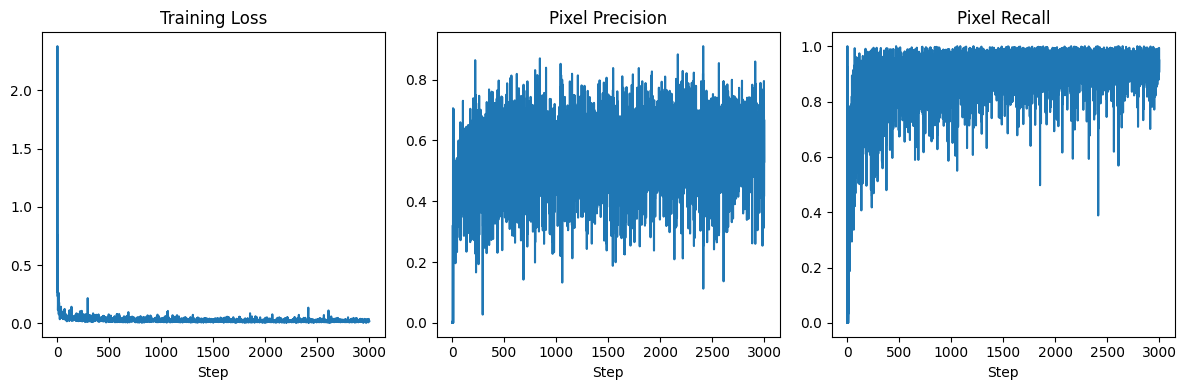


Sweeping thresholds...
{'threshold': 0.5, 'tp': 845, 'fp': 305, 'fn': 32, 'precision': 0.7347826086892628, 'recall': 0.963511972622993, 'f1': 0.8337444450084687, 'mean_loc_error': 0.4633752351924336}
{'threshold': 0.45, 'tp': 846, 'fp': 350, 'fn': 31, 'precision': 0.7073578595258583, 'recall': 0.9646522234781681, 'f1': 0.8162083887429425, 'mean_loc_error': 0.4552105050247788}
{'threshold': 0.4, 'tp': 850, 'fp': 404, 'fn': 27, 'precision': 0.6778309409834304, 'recall': 0.9692132268988687, 'f1': 0.7977475315169053, 'mean_loc_error': 0.4568280951678753}
{'threshold': 0.35, 'tp': 854, 'fp': 452, 'fn': 23, 'precision': 0.653905053593768, 'recall': 0.9737742303195692, 'f1': 0.7824095233581696, 'mean_loc_error': 0.4568668029814156}
{'threshold': 0.3, 'tp': 855, 'fp': 512, 'fn': 22, 'precision': 0.6254572055550442, 'recall': 0.9749144811747444, 'f1': 0.7620320807931114, 'mean_loc_error': 0.4480389196752456}
{'threshold': 0.25, 'tp': 857, 'fp': 591, 'fn': 20, 'precision': 0.5918508287251945, '

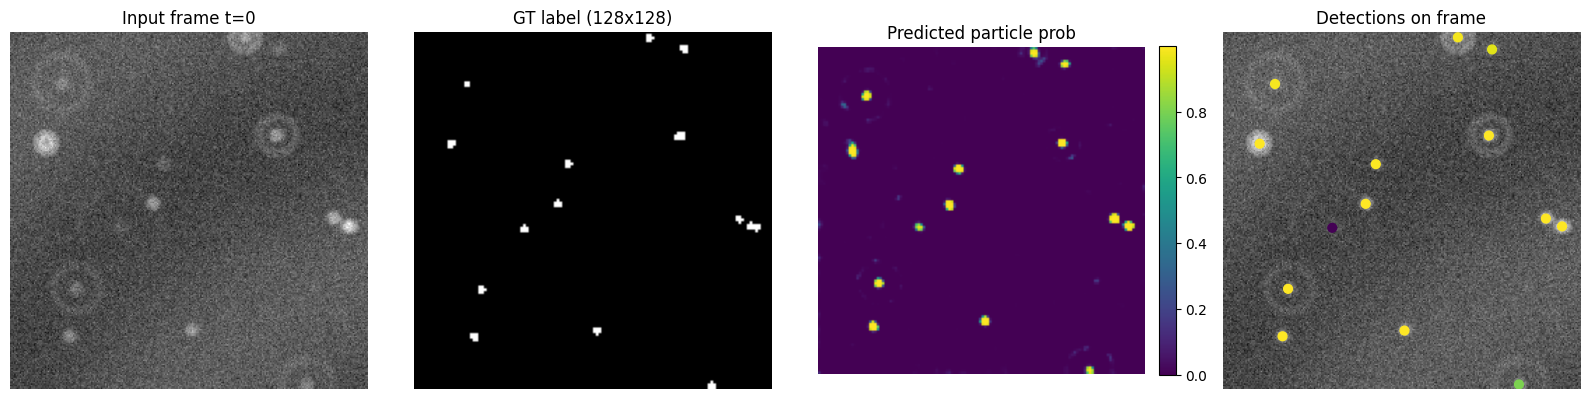

In [2]:
# ============================================================
# Single clean notebook cell for:
# training -> probability map -> detections -> linking -> eval
#
# Assumes this class already exists 9in your notebook:
#   Particle_Tracking_Training_Data
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy import ndimage

# ------------------------------------------------------------
# 0) Reproducibility
# ------------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------------------------------
# 1) Data generation
# ------------------------------------------------------------
def random_generator_params():
    return {
        "kappa": np.float32(np.random.uniform(0.05, 0.20)),
        "a": np.float32(np.random.uniform(1.5, 4.0)),
        "IbackLevel": np.float32(np.random.uniform(0.0, 0.4)),
        "Nparticles": np.int32(np.random.randint(5, 20)),
        "sigma_motion": np.float32(np.random.uniform(0.5, 4.0)),
    }

def make_one_example(pt, params=None):
    if params is None:
        params = random_generator_params()

    vid, labels, tracks = pt(
        params["kappa"],
        params["a"],
        params["IbackLevel"],
        params["Nparticles"],
        params["sigma_motion"],
    )

    vid = tf.cast(vid, tf.float32)[..., tf.newaxis]   # (T, 256, 256, 1)
    labels = tf.cast(labels, tf.float32)              # (T, 128, 128, 2)

    return vid, labels, tracks, params

def training_data_generator(pt):
    while True:
        vid, labels, _, _ = make_one_example(pt)
        yield vid.numpy(), labels.numpy()

def make_dataset(pt, batch_size=2):
    output_signature = (
        tf.TensorSpec(shape=(pt.Nt, pt.Ny, pt.Nx, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(pt.Nt, pt.Ny // 2, pt.Nx // 2, 2), dtype=tf.float32),
    )

    ds = tf.data.Dataset.from_generator(
        lambda: training_data_generator(pt),
        output_signature=output_signature,
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# ------------------------------------------------------------
# 2) Forward-backward model
# ------------------------------------------------------------
class PaperStyleTrackerFB(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.act = tf.nn.softplus

        # frame feature extractor
        self.conv1_9 = tf.keras.layers.Conv2D(3, 9, strides=2, padding="same")
        self.conv1_5 = tf.keras.layers.Conv2D(3, 5, strides=2, padding="same")
        self.conv1_3 = tf.keras.layers.Conv2D(3, 3, strides=1, padding="same")
        self.pool1_3 = tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding="same")

        self.conv2_7 = tf.keras.layers.Conv2D(6, 7, strides=1, dilation_rate=2, padding="same")
        self.conv2_3 = tf.keras.layers.Conv2D(6, 3, strides=1, dilation_rate=2, padding="same")

        # forward recurrence
        self.fwd_in = tf.keras.layers.Conv2D(6, 7, strides=1, dilation_rate=2, padding="same")
        self.fwd_h  = tf.keras.layers.Conv2D(6, 7, strides=1, dilation_rate=2, padding="same")

        # backward recurrence
        self.bwd_in = tf.keras.layers.Conv2D(6, 7, strides=1, dilation_rate=2, padding="same")
        self.bwd_h  = tf.keras.layers.Conv2D(6, 7, strides=1, dilation_rate=2, padding="same")

        # output logits
        self.out_conv = tf.keras.layers.Conv2D(2, 5, strides=1, padding="same")

    def normalize_frame(self, x):
        mean, var = tf.nn.moments(x, axes=[1, 2, 3], keepdims=True)
        return (x - mean) / tf.sqrt(var + 1e-6)

    def frame_encoder(self, x):
        x = self.normalize_frame(x)

        l1a = self.act(self.conv1_9(x))        # (B,128,128,3)
        l1b = self.act(self.conv1_5(x))        # (B,128,128,3)

        l1c = self.act(self.conv1_3(x))        # (B,256,256,3)
        l1c = self.pool1_3(l1c)                # (B,128,128,3)

        l1 = tf.concat([l1a, l1b, l1c], axis=-1)   # (B,128,128,9)

        l2a = self.act(self.conv2_7(l1))       # (B,128,128,6)
        l2b = self.act(self.conv2_3(l1))       # (B,128,128,6)

        return l2a, l2b

    def call(self, video, training=False):
        # video: (B,T,256,256,1)
        frames = tf.unstack(video, axis=1)

        feat_a = []
        feat_b = []
        for x in frames:
            l2a, l2b = self.frame_encoder(x)
            feat_a.append(l2a)
            feat_b.append(l2b)

        # forward pass
        h_f = tf.zeros_like(feat_a[0])
        fwd_states = []
        for x in feat_a:
            h_f = self.act(self.fwd_in(x) + self.fwd_h(h_f))
            fwd_states.append(h_f)

        # backward pass
        h_b = tf.zeros_like(feat_a[0])
        bwd_states_rev = []
        for x in reversed(feat_a):
            h_b = self.act(self.bwd_in(x) + self.bwd_h(h_b))
            bwd_states_rev.append(h_b)
        bwd_states = list(reversed(bwd_states_rev))

        outputs = []
        for l2a, l2b, hf, hb in zip(feat_a, feat_b, fwd_states, bwd_states):
            fused = tf.concat([l2a, l2b, hf, hb], axis=-1)   # (B,128,128,24)
            logits = self.out_conv(fused)                    # (B,128,128,2)
            outputs.append(logits)

        return tf.stack(outputs, axis=1)   # (B,T,128,128,2)

# ------------------------------------------------------------
# 3) Loss, optimizer, training
# ------------------------------------------------------------
def weighted_particle_cce(labels, logits, pos_weight=12.0):
    """
    labels: one-hot (..., 2)
    logits: raw logits (..., 2)
    """
    per_pixel_ce = tf.keras.losses.categorical_crossentropy(
        labels, logits, from_logits=True
    )  # (...,)

    pos_mask = labels[..., 1]  # particle channel
    weights = 1.0 + (pos_weight - 1.0) * pos_mask

    return tf.reduce_sum(per_pixel_ce * weights) / (tf.reduce_sum(weights) + 1e-8)

def particle_pixel_metrics(logits, labels, threshold=0.5):
    probs = tf.nn.softmax(logits, axis=-1)[..., 1]
    pred = probs >= threshold
    true = labels[..., 1] > 0.5

    tp = tf.reduce_sum(tf.cast(tf.logical_and(pred, true), tf.float32))
    fp = tf.reduce_sum(tf.cast(tf.logical_and(pred, tf.logical_not(true)), tf.float32))
    fn = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(pred), true), tf.float32))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return precision, recall

def make_optimizer(mode="adam"):
    if mode == "adam":
        return tf.keras.optimizers.Adam(learning_rate=1e-3)
    elif mode == "sgd":
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=0.16,
            decay_steps=1000,
            decay_rate=0.95,
            staircase=True,
        )
        return tf.keras.optimizers.SGD(
            learning_rate=lr_schedule,
            clipnorm=1.0,
        )
    else:
        raise ValueError("mode must be 'adam' or 'sgd'")

def train_step_weighted(model, videos, labels, optimizer, pos_weight=12.0):
    with tf.GradientTape() as tape:
        logits = model(videos, training=True)
        loss = weighted_particle_cce(labels, logits, pos_weight=pos_weight)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    pix_prec, pix_rec = particle_pixel_metrics(logits, labels, threshold=0.5)
    return loss, pix_prec, pix_rec

def train_model_weighted(model, dataset, optimizer, steps=3000, pos_weight=12.0, print_every=100):
    history = {"loss": [], "pix_prec": [], "pix_rec": []}
    it = iter(dataset)

    for step in range(1, steps + 1):
        videos, labels = next(it)

        if step == 1:
            print("videos shape:", videos.shape)
            print("labels shape:", labels.shape)

        loss, pix_prec, pix_rec = train_step_weighted(
            model, videos, labels, optimizer, pos_weight=pos_weight
        )

        history["loss"].append(float(loss.numpy()))
        history["pix_prec"].append(float(pix_prec.numpy()))
        history["pix_rec"].append(float(pix_rec.numpy()))

        if step % print_every == 0:
            print(
                f"step={step:5d} "
                f"loss={loss.numpy():.4f} "
                f"pix_prec={pix_prec.numpy():.4f} "
                f"pix_rec={pix_rec.numpy():.4f}"
            )

    return history

# ------------------------------------------------------------
# 4) Probability map -> detections
# ------------------------------------------------------------
def predict_probability_map(model, video):
    """
    video:
      (T,H,W,1) or (B,T,H,W,1)
    returns:
      (T,h,w) or (B,T,h,w), particle probability channel
    """
    video = tf.convert_to_tensor(video, dtype=tf.float32)

    single_video = (video.ndim == 4)
    if single_video:
        video = video[None, ...]

    logits = model(video, training=False)           # (B,T,128,128,2)
    probs = tf.nn.softmax(logits, axis=-1)[..., 1]  # particle channel

    probs = probs.numpy()
    if single_video:
        probs = probs[0]

    return probs

def probmap_to_particles_one_frame(prob_map, threshold=0.5, scale_xy=2.0):
    """
    prob_map: (h,w), here usually (128,128)
    scale_xy=2.0 maps low-res output back to original 256x256 frame
    """
    mask = prob_map >= threshold

    structure = np.ones((3, 3), dtype=np.uint8)  # 8-connectivity
    cc, n_comp = ndimage.label(mask.astype(np.uint8), structure=structure)

    detections = []
    for comp_id in range(1, n_comp + 1):
        ys, xs = np.where(cc == comp_id)
        if len(xs) == 0:
            continue

        weights = prob_map[ys, xs].astype(np.float64)
        wsum = weights.sum()
        if wsum <= 0:
            continue

        y_c = float(np.sum(ys * weights) / wsum)
        x_c = float(np.sum(xs * weights) / wsum)
        rho = float(np.max(weights))

        detections.append({
            "xy": np.array([x_c * scale_xy, y_c * scale_xy], dtype=np.float32),
            "xy_lowres": np.array([x_c, y_c], dtype=np.float32),
            "prob": rho,
            "area": int(len(xs)),
        })

    return detections

def probability_maps_to_detections(prob_maps, threshold=0.5, scale_xy=2.0):
    detections = []
    T = prob_maps.shape[0]
    for t in range(T):
        detections.append(
            probmap_to_particles_one_frame(
                prob_maps[t], threshold=threshold, scale_xy=scale_xy
            )
        )
    return detections

# ------------------------------------------------------------
# 5) Linking detections across frames
# ------------------------------------------------------------
def _clip_prob(p, eps=1e-6):
    return float(np.clip(p, eps, 1.0 - eps))

def build_link_cost_matrix(dets_t, dets_tp1, sigma=20.0):
    n = len(dets_t)
    m = len(dets_tp1)
    BIG = 1e9

    C = np.full((n + m, n + m), BIG, dtype=np.float64)

    # real-real match costs
    for i in range(n):
        xi = dets_t[i]["xy"].astype(np.float64)
        rhoi = _clip_prob(dets_t[i]["prob"])

        for j in range(m):
            xj = dets_tp1[j]["xy"].astype(np.float64)
            rhoj = _clip_prob(dets_tp1[j]["prob"])

            dist2 = np.sum((xi - xj) ** 2)
            cost_match = dist2 / (2.0 * sigma * sigma) - np.log(rhoi) - np.log(rhoj)
            C[i, j] = cost_match

    # unmatched in frame t
    for i in range(n):
        rhoi = _clip_prob(dets_t[i]["prob"])
        C[i, m + i] = -np.log(1.0 - rhoi)

    # unmatched in frame t+1
    for j in range(m):
        rhoj = _clip_prob(dets_tp1[j]["prob"])
        C[n + j, j] = -np.log(1.0 - rhoj)

    # dummy-dummy
    C[n:, m:] = 0.0

    return C

def solve_frame_linking(dets_t, dets_tp1, sigma=20.0):
    n = len(dets_t)
    m = len(dets_tp1)

    if n == 0 and m == 0:
        return [], [], []
    if n == 0:
        return [], [], list(range(m))
    if m == 0:
        return [], list(range(n)), []

    C = build_link_cost_matrix(dets_t, dets_tp1, sigma=sigma)
    rows, cols = linear_sum_assignment(C)

    matches = []
    unmatched_t = []
    unmatched_tp1 = []

    for r, c in zip(rows, cols):
        if r < n and c < m:
            matches.append((r, c))
        elif r < n and c >= m and (c - m) == r:
            unmatched_t.append(r)
        elif r >= n and c < m and (r - n) == c:
            unmatched_tp1.append(c)

    return matches, unmatched_t, unmatched_tp1

def link_detections_to_tracks(detections, sigma=20.0):
    T = len(detections)
    if T == 0:
        return []

    tracks = {}
    next_track_id = 0

    # init from frame 0
    for det in detections[0]:
        tid = next_track_id
        next_track_id += 1
        det["track_id"] = tid
        tracks[tid] = {
            "id": tid,
            "frames": [0],
            "xy": [det["xy"]],
            "prob": [det["prob"]],
        }

    # link frame by frame
    for t in range(T - 1):
        dets_t = detections[t]
        dets_tp1 = detections[t + 1]

        matches, unmatched_t, unmatched_tp1 = solve_frame_linking(
            dets_t, dets_tp1, sigma=sigma
        )

        for i, j in matches:
            tid = dets_t[i]["track_id"]
            dets_tp1[j]["track_id"] = tid
            tracks[tid]["frames"].append(t + 1)
            tracks[tid]["xy"].append(dets_tp1[j]["xy"])
            tracks[tid]["prob"].append(dets_tp1[j]["prob"])

        for j in unmatched_tp1:
            tid = next_track_id
            next_track_id += 1
            dets_tp1[j]["track_id"] = tid
            tracks[tid] = {
                "id": tid,
                "frames": [t + 1],
                "xy": [dets_tp1[j]["xy"]],
                "prob": [dets_tp1[j]["prob"]],
            }

    out = []
    for tid in sorted(tracks.keys()):
        tr = tracks[tid]
        out.append({
            "id": tr["id"],
            "frames": np.asarray(tr["frames"], dtype=np.int32),
            "xy": np.asarray(tr["xy"], dtype=np.float32),
            "prob": np.asarray(tr["prob"], dtype=np.float32),
        })
    return out

def run_tracker_on_video(model, video, threshold=0.5, sigma=20.0, scale_xy=2.0):
    prob_maps = predict_probability_map(model, video)
    detections = probability_maps_to_detections(
        prob_maps, threshold=threshold, scale_xy=scale_xy
    )
    tracks = link_detections_to_tracks(detections, sigma=sigma)
    return prob_maps, detections, tracks

# ------------------------------------------------------------
# 6) Detection evaluation
# ------------------------------------------------------------
def gt_points_by_frame(gt_tracks, image_shape=(256, 256), only_visible=True):
    if tf.is_tensor(gt_tracks):
        gt_tracks = gt_tracks.numpy()

    gt_tracks = np.asarray(gt_tracks, dtype=np.float32)
    T = gt_tracks.shape[0]
    H, W = image_shape

    out = []
    for t in range(T):
        pts = gt_tracks[t, :, :2]   # x,y only

        if only_visible:
            keep = (
                (pts[:, 0] >= 0) & (pts[:, 0] < W) &
                (pts[:, 1] >= 0) & (pts[:, 1] < H)
            )
            pts = pts[keep]

        out.append(np.asarray(pts, dtype=np.float32).reshape(-1, 2))

    return out

def match_points(pred_xy, gt_xy, match_radius=5.0):
    pred_xy = np.asarray(pred_xy, dtype=np.float32).reshape(-1, 2)
    gt_xy = np.asarray(gt_xy, dtype=np.float32).reshape(-1, 2)

    n_pred = len(pred_xy)
    n_gt = len(gt_xy)

    if n_pred == 0 and n_gt == 0:
        return [], [], []
    if n_pred == 0:
        return [], [], list(range(n_gt))
    if n_gt == 0:
        return [], list(range(n_pred)), []

    dmat = np.linalg.norm(pred_xy[:, None, :] - gt_xy[None, :, :], axis=-1)
    rows, cols = linear_sum_assignment(dmat)

    matches = []
    matched_pred = set()
    matched_gt = set()

    for r, c in zip(rows, cols):
        dist = float(dmat[r, c])
        if dist <= match_radius:
            matches.append((int(r), int(c), dist))
            matched_pred.add(int(r))
            matched_gt.add(int(c))

    unmatched_pred = [i for i in range(n_pred) if i not in matched_pred]
    unmatched_gt   = [j for j in range(n_gt) if j not in matched_gt]

    return matches, unmatched_pred, unmatched_gt

def evaluate_detections(detections, gt_tracks, match_radius=5.0, image_shape=(256, 256)):
    gt_by_t = gt_points_by_frame(gt_tracks, image_shape=image_shape, only_visible=True)

    tp = 0
    fp = 0
    fn = 0
    errors = []
    per_frame = []

    T = len(detections)
    for t in range(T):
        if len(detections[t]) == 0:
            pred_xy = np.zeros((0, 2), dtype=np.float32)
        else:
            pred_xy = np.stack(
                [np.asarray(d["xy"], dtype=np.float32).reshape(2,) for d in detections[t]],
                axis=0
            )

        gt_xy = gt_by_t[t]
        matches, unmatched_pred, unmatched_gt = match_points(
            pred_xy, gt_xy, match_radius=match_radius
        )

        tp_t = len(matches)
        fp_t = len(unmatched_pred)
        fn_t = len(unmatched_gt)

        tp += tp_t
        fp += fp_t
        fn += fn_t
        errors.extend([m[2] for m in matches])

        per_frame.append({
            "frame": t,
            "n_pred": int(len(pred_xy)),
            "n_gt": int(len(gt_xy)),
            "tp": int(tp_t),
            "fp": int(fp_t),
            "fn": int(fn_t),
            "matches": matches,
        })

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mean_loc_error": float(np.mean(errors)) if len(errors) > 0 else np.nan,
        "median_loc_error": float(np.median(errors)) if len(errors) > 0 else np.nan,
        "n_matches": int(len(errors)),
        "per_frame": per_frame,
    }

def evaluate_model_on_examples(
    model,
    pt,
    num_examples=10,
    threshold=0.5,
    sigma=20.0,
    match_radius=5.0,
    scale_xy=2.0,
):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    all_errors = []
    all_num_tracks = []
    all_avg_track_len = []

    for ex in range(num_examples):
        video, labels, gt_tracks, params = make_one_example(pt)

        prob_maps, detections, tracks = run_tracker_on_video(
            model,
            video,
            threshold=threshold,
            sigma=sigma,
            scale_xy=scale_xy,
        )

        metrics = evaluate_detections(
            detections,
            gt_tracks,
            match_radius=match_radius,
            image_shape=(pt.Ny, pt.Nx),
        )

        total_tp += metrics["tp"]
        total_fp += metrics["fp"]
        total_fn += metrics["fn"]

        for pf in metrics["per_frame"]:
            all_errors.extend([m[2] for m in pf["matches"]])

        all_num_tracks.append(len(tracks))
        avg_len = np.mean([len(tr["frames"]) for tr in tracks]) if len(tracks) > 0 else 0.0
        all_avg_track_len.append(float(avg_len))

        print(
            f"example {ex+1:2d}/{num_examples} | "
            f"TP={metrics['tp']:3d} FP={metrics['fp']:3d} FN={metrics['fn']:3d} | "
            f"F1={metrics['f1']:.3f}"
        )

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall    = total_tp / (total_tp + total_fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "num_examples": int(num_examples),
        "threshold": float(threshold),
        "sigma": float(sigma),
        "match_radius": float(match_radius),
        "tp": int(total_tp),
        "fp": int(total_fp),
        "fn": int(total_fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mean_loc_error": float(np.mean(all_errors)) if len(all_errors) > 0 else np.nan,
        "median_loc_error": float(np.median(all_errors)) if len(all_errors) > 0 else np.nan,
        "avg_num_tracks": float(np.mean(all_num_tracks)) if len(all_num_tracks) > 0 else 0.0,
        "avg_track_len": float(np.mean(all_avg_track_len)) if len(all_avg_track_len) > 0 else 0.0,
    }

def print_metrics(metrics):
    print("\n==== Evaluation Summary ====")
    print(f"TP               : {metrics['tp']}")
    print(f"FP               : {metrics['fp']}")
    print(f"FN               : {metrics['fn']}")
    print(f"Precision        : {metrics['precision']:.4f}")
    print(f"Recall           : {metrics['recall']:.4f}")
    print(f"F1               : {metrics['f1']:.4f}")
    print(f"Mean loc error   : {metrics['mean_loc_error']:.4f}")
    print(f"Median loc error : {metrics['median_loc_error']:.4f}")
    if "avg_num_tracks" in metrics:
        print(f"Avg # tracks     : {metrics['avg_num_tracks']:.2f}")
        print(f"Avg track length : {metrics['avg_track_len']:.2f}")

# ------------------------------------------------------------
# 7) Threshold sweep
# ------------------------------------------------------------
def sweep_thresholds(
    model,
    pt,
    thresholds=(0.25, 0.30, 0.35, 0.40, 0.45, 0.50),
    num_examples=10,
    sigma=20.0,
    match_radius=5.0,
    scale_xy=2.0,
):
    results = []

    # same validation set for fair comparison
    examples = [make_one_example(pt) for _ in range(num_examples)]

    for thr in thresholds:
        total_tp = 0
        total_fp = 0
        total_fn = 0
        all_errors = []

        for video, labels, gt_tracks, params in examples:
            prob_maps = predict_probability_map(model, video)
            detections = probability_maps_to_detections(
                prob_maps, threshold=thr, scale_xy=scale_xy
            )

            metrics = evaluate_detections(
                detections,
                gt_tracks,
                match_radius=match_radius,
                image_shape=(pt.Ny, pt.Nx),
            )

            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]

            for pf in metrics["per_frame"]:
                all_errors.extend([m[2] for m in pf["matches"]])

        precision = total_tp / (total_tp + total_fp + 1e-8)
        recall    = total_tp / (total_tp + total_fn + 1e-8)
        f1        = 2 * precision * recall / (precision + recall + 1e-8)

        results.append({
            "threshold": float(thr),
            "tp": int(total_tp),
            "fp": int(total_fp),
            "fn": int(total_fn),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "mean_loc_error": float(np.mean(all_errors)) if len(all_errors) > 0 else np.nan,
        })

    return sorted(results, key=lambda x: x["f1"], reverse=True)

# ------------------------------------------------------------
# 8) Visualization
# ------------------------------------------------------------
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(history["loss"])
    plt.title("Training Loss")
    plt.xlabel("Step")

    plt.subplot(1, 3, 2)
    plt.plot(history["pix_prec"])
    plt.title("Pixel Precision")
    plt.xlabel("Step")

    plt.subplot(1, 3, 3)
    plt.plot(history["pix_rec"])
    plt.title("Pixel Recall")
    plt.xlabel("Step")

    plt.tight_layout()
    plt.show()

def show_one_result(model, pt, threshold=0.5, sigma=20.0, scale_xy=2.0, t=0):
    video, labels, gt_tracks, params = make_one_example(pt)

    prob_maps, detections, tracks = run_tracker_on_video(
        model,
        video,
        threshold=threshold,
        sigma=sigma,
        scale_xy=scale_xy,
    )

    metrics = evaluate_detections(
        detections,
        gt_tracks,
        match_radius=5.0,
        image_shape=(pt.Ny, pt.Nx),
    )

    print("\nSingle example params:", params)
    print(f"frame {t}: detections={len(detections[t])}, tracks={len(tracks)}")
    print(f"example precision={metrics['precision']:.4f}, recall={metrics['recall']:.4f}, f1={metrics['f1']:.4f}")

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(video[t, ..., 0], cmap="gray")
    plt.title(f"Input frame t={t}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(labels[t, ..., 1], cmap="gray")
    plt.title("GT label (128x128)")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(prob_maps[t], cmap="viridis")
    plt.title("Predicted particle prob")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(video[t, ..., 0], cmap="gray")
    if len(detections[t]) > 0:
        xs = [d["xy"][0] for d in detections[t]]
        ys = [d["xy"][1] for d in detections[t]]
        ps = [d["prob"] for d in detections[t]]
        plt.scatter(xs, ys, c=ps, s=40)
    plt.title("Detections on frame")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 9) Main run
# ------------------------------------------------------------
# Good starting settings:
# - increase TRAIN_STEPS to 5000 or 10000 for better results
# - POS_WEIGHT in [8, 20] is usually worth trying
# - lower threshold often helps recall

NT = 8
BATCH_SIZE = 2
TRAIN_STEPS = 3000      # try 5000 or 10000 later
POS_WEIGHT = 12.0
OPT_MODE = "sgd"       # "adam" is stable; "sgd" is closer to paper
SIGMA_LINK = 20.0
MATCH_RADIUS = 5.0
SCALE_XY = 2.0          # model output is 128x128, original frame is 256x256

print("Creating generator and dataset...")
pt = Particle_Tracking_Training_Data(Nt=NT, rings=True)
dataset = make_dataset(pt, batch_size=BATCH_SIZE)

videos0, labels0 = next(iter(dataset))
print("pt.Nt =", pt.Nt)
print("pt.Ny =", pt.Ny)
print("pt.Nx =", pt.Nx)
print("dataset videos shape:", videos0.shape)
print("dataset labels shape:", labels0.shape)

print("\nBuilding model...")
model = PaperStyleTrackerFB()
_ = model(videos0, training=False)
print("model output logits shape:", model(videos0, training=False).shape)

print("\nTraining...")
optimizer = make_optimizer(mode=OPT_MODE)
history = train_model_weighted(
    model,
    dataset,
    optimizer,
    steps=TRAIN_STEPS,
    pos_weight=POS_WEIGHT,
    print_every=100,
)

plot_training_history(history)

print("\nSweeping thresholds...")
thr_results = sweep_thresholds(
    model,
    pt,
    thresholds=(0.25, 0.30, 0.35, 0.40, 0.45, 0.50),
    num_examples=10,
    sigma=SIGMA_LINK,
    match_radius=MATCH_RADIUS,
    scale_xy=SCALE_XY,
)

for r in thr_results:
    print(r)

best_thr = thr_results[0]["threshold"]
print("\nBest threshold from sweep:", best_thr)

print("\nFinal evaluation...")
metrics = evaluate_model_on_examples(
    model,
    pt,
    num_examples=20,
    threshold=best_thr,
    sigma=SIGMA_LINK,
    match_radius=MATCH_RADIUS,
    scale_xy=SCALE_XY,
)
print_metrics(metrics)

print("\nShowing one example...")
show_one_result(
    model,
    pt,
    threshold=best_thr,
    sigma=SIGMA_LINK,
    scale_xy=SCALE_XY,
    t=0,
)